# Bregman Proximal Gradient Method (BPGM)

This notebook applies the systematic Lyapunov-function discovery procedure to the Bregman proximal gradient method with step size $1/L$:
$$
x_{k+1}\in\operatorname*{argmin}_{y\in C}\left\{f(y)+\langle\nabla g(x_k),y-x_k\rangle+LD_h(y,x_k)\right\},
$$
for composite convex minimization $F=f+g$, where $f$ is proximable and $g$ is relatively $L$-smooth with respect to the Legendre-type Bregman kernel $h$. Its rate $F(x_N)-F(x_\diamond)\le \frac{L}{N}D_h(x_\diamond,x_0)$ was shown in "A simple convergence analysis of Bregman proximal gradient algorithm" by Zhou, Liang, and Shen (2019), and is also a special case of "Perturbed Fenchel duality and first-order methods" by Gutman and Pena (2023).


## Import the required libraries

In [1]:
import pepflow as pf
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt
import itertools
from IPython.display import display, Math
import pepflow.lyapunov_utils as lu

## Define the functions and parameters

In [2]:
L = pf.Parameter("L")
R = pf.Parameter("R")

f = pf.ConvexFunction(is_basis=True, tags=["f"])
g = pf.ConvexFunction(is_basis=True, tags=["g"])
h = pf.ConvexFunction(is_basis=True, tags=["h"])
F = (f + g).add_tag("F")

Define a helper for the relative-smoothness inequality.

In [3]:
def relative_smoothness_ineq(h_func, g_func, x_i, x_j, L_param):
    return (
        h_func(x_j)
        - h_func(x_i)
        - (g_func(x_j) - g_func(x_i)) / L_param
        + (h_func.grad(x_j) - g_func.grad(x_j) / L_param) * (x_i - x_j)
    )

## Write a function to return the PEPContext for BPGM

In [4]:
def make_ctx_bpgm(ctx_name: str, N: int | sp.Integer) -> pf.PEPContext:
    ctx = pf.PEPContext(ctx_name).set_as_current()
    x = pf.Vector(is_basis=True, tags=["x_0"])

    for k in range(int(N)):
        grad_g_x = g.grad(x)
        grad_h_x = h.grad(x)

        x_next = pf.Vector(is_basis=True, tags=[f"x_{k + 1}"])
        grad_h_next = h.grad(x_next)
        grad_f_next = -grad_g_x - L * (grad_h_next - grad_h_x)
        grad_f_next.math_expr.expr_str = f"grad_f({x_next})"
        f.add_point_with_grad_restriction(x_next, grad_f_next)
        x = x_next

    pf.Vector(is_basis=True, tags=[r"x_\diamond"])
    return ctx

## PEP builder for BPGM

In [5]:
def make_pep_bpgm(ctx_name: str, N: int | sp.Integer):
    ctx = make_ctx_bpgm(ctx_name, N)
    pb = pf.PEPBuilder(ctx)
    point_tags = [f"x_{i}" for i in range(int(N) + 1)] + [r"x_\diamond"]
    points = [ctx[tag] for tag in point_tags]
    for x_i, x_j in itertools.product(points, points):
        if x_i == x_j:
            continue
        pb.add_initial_constraint(
            relative_smoothness_ineq(h, g, x_i, x_j, L).le(
                0,
                name=f"relative_smoothness:{x_i},{x_j}",
            )
        )
    pb.add_initial_constraint(
        (-h.interp_ineq(r"x_\diamond", "x_0", pep_context=ctx)).le(
            R,
            name="initial_condition",
        )
    )
    pb.set_performance_metric(F(ctx[f"x_{N}"]) - F(ctx[r"x_\diamond"]))
    return ctx, pb

## Numerical evidence showing that BPGM converges at the rate $F(x_N)-F(x_\diamond)\le \frac{LR}{N}$


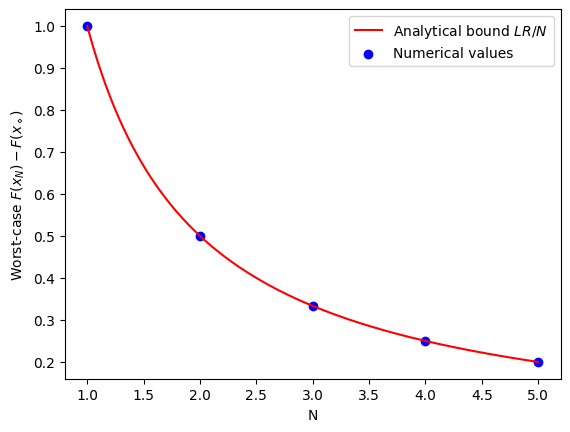

In [6]:
N_max = 5
L_value = 1
R_value = 1

opt_values = []
for N_i in range(1, N_max + 1):
    ctx_i, pb_i = make_pep_bpgm(ctx_name=f"ctx_plt_{N_i}", N=N_i)
    result_i = pb_i.solve(resolve_parameters={"L": L_value, "R": R_value})
    opt_values.append(result_i.opt_value)

iters = np.arange(1, N_max + 1)
cont_iters = np.arange(1, N_max + 0.01, 0.01)
plt.plot(
    cont_iters,
    L_value * R_value / cont_iters,
    "r-",
    label="Analytical bound $LR/N$",
)
plt.scatter(iters, opt_values, color="blue", marker="o", label="Numerical values")
plt.xlabel("N")
plt.ylabel(r"Worst-case $F(x_N)-F(x_\diamond)$")
plt.legend()

## Verification of convergence of BPGM

In [7]:
N = 5
L_value = 1
R_value = 1


def bpgm_relaxed_constraints_from_sparse_pattern(N: int | sp.Integer):
    relaxed = []
    N = int(N)
    diamond = r"x_\diamond"
    point_tags = [f"x_{i}" for i in range(N + 1)] + [diamond]
    pairs = [(row, col) for row in point_tags for col in point_tags if row != col]

    keep_f = {(diamond, f"x_{j}") for j in range(1, N + 1)}
    keep_f.update((f"x_{j - 1}", f"x_{j}") for j in range(2, N + 1))

    keep_g = {(diamond, f"x_{j}") for j in range(N)}
    keep_g.update((f"x_{j - 1}", f"x_{j}") for j in range(2, N + 1))

    keep_relative = {(f"x_{j}", f"x_{j - 1}") for j in range(1, N + 1)}
    keep_relative.update((f"x_{j - 1}", f"x_{j}") for j in range(2, N + 1))

    keep_h = {(diamond, f"x_{N}")}

    for row, col in pairs:
        if (row, col) not in keep_f:
            relaxed.append(f"f:{row},{col}")
        if (row, col) not in keep_g:
            relaxed.append(f"g:{row},{col}")
        if (row, col) not in keep_h:
            relaxed.append(f"h:{row},{col}")
        if (row, col) not in keep_relative:
            relaxed.append(f"relative_smoothness:{row},{col}")
    return relaxed


ctx_prf, pb_prf = make_pep_bpgm("ctx_prf", N)
pb_prf.set_relaxed_constraints(bpgm_relaxed_constraints_from_sparse_pattern(N))
result = pb_prf.solve(resolve_parameters={"L": L_value, "R": R_value})
print(result.opt_value)

0.19999982708500524


### Store the solver output and matrix labels used below

In [8]:
def relative_dual_matrix(result, N):
    names = [f"x_{i}" for i in range(int(N) + 1)] + [r"x_\diamond"]
    matrix = np.zeros((len(names), len(names)))
    for i, row in enumerate(names):
        for j, col in enumerate(names):
            if row != col:
                matrix[i, j] = (
                    result.get_dual_value(f"relative_smoothness:{row},{col}") or 0.0
                )
    return pf.MatrixWithNames(matrix, row_names=names, col_names=names)


tau_sol = result.dual_var_manager.dual_value("initial_condition")

f_lamb_sol = result.get_scalar_constraint_dual_value_in_numpy(f)
g_lamb_sol = result.get_scalar_constraint_dual_value_in_numpy(g)
h_lamb_sol = result.get_scalar_constraint_dual_value_in_numpy(h)
rel_lamb_sol = relative_dual_matrix(result, N)

S_sol = result.get_gram_dual_matrix()

In [9]:
f_lamb_sol.pprint()

<IPython.core.display.Math object>

In [10]:
g_lamb_sol.pprint()

<IPython.core.display.Math object>

In [11]:
h_lamb_sol.pprint()

<IPython.core.display.Math object>

In [12]:
rel_lamb_sol.pprint()

<IPython.core.display.Math object>

In [13]:
S_sol.pprint()

<IPython.core.display.Math object>

---

## Step 1. Propose a candidate Lyapunov function

### Let
$$
\begin{aligned}
\mathcal I^f_0&=\emptyset,
&\mathcal I^f_k&=\{(\diamond,j):j=1,\ldots,k\}\cup\{(j-1,j):j=2,\ldots,k\},\\
\mathcal I^g_0&=\emptyset,
&\mathcal I^g_k&=\{(\diamond,j):j=0,\ldots,k-1\}\cup\{(j-1,j):j=2,\ldots,k\},\\
\mathcal I^{h-g/L}_0&=\emptyset,
&\mathcal I^{h-g/L}_k&=\{(j,j-1):j=1,\ldots,k\}\cup\{(j-1,j):j=2,\ldots,k\}
\end{aligned}
$$
### for $k=1,\ldots,N$, and let $\mathcal J_k=\emptyset$ for $k=0,\ldots,N$.


In [14]:
def rationalize_dual_value(lamb_matrix, row_name: str, col_name: str):
    return sp.nsimplify(lamb_matrix(row_name, col_name), rational=True, tolerance=1e-5)


V = [pf.Scalar.zero()]
partial_sum = pf.Scalar.zero()
x_diamond = r"x_\diamond"

for j in range(1, int(N) + 1):
    x_prev_tag = f"x_{j - 1}"
    x_curr_tag = f"x_{j}"

    partial_sum += rationalize_dual_value(
        f_lamb_sol, x_diamond, x_curr_tag
    ) * f.interp_ineq(x_diamond, x_curr_tag, pep_context=ctx_prf)
    partial_sum += rationalize_dual_value(
        g_lamb_sol, x_diamond, x_prev_tag
    ) * g.interp_ineq(x_diamond, x_prev_tag, pep_context=ctx_prf)
    partial_sum += rationalize_dual_value(
        rel_lamb_sol, x_curr_tag, x_prev_tag
    ) * relative_smoothness_ineq(h, g, ctx_prf[x_curr_tag], ctx_prf[x_prev_tag], L)

    if j >= 2:
        partial_sum += rationalize_dual_value(
            f_lamb_sol, x_prev_tag, x_curr_tag
        ) * f.interp_ineq(x_prev_tag, x_curr_tag, pep_context=ctx_prf)
        partial_sum += rationalize_dual_value(
            g_lamb_sol, x_prev_tag, x_curr_tag
        ) * g.interp_ineq(x_prev_tag, x_curr_tag, pep_context=ctx_prf)
        partial_sum += rationalize_dual_value(
            rel_lamb_sol, x_prev_tag, x_curr_tag
        ) * relative_smoothness_ineq(h, g, ctx_prf[x_prev_tag], ctx_prf[x_curr_tag], L)

    V.append(partial_sum)

print("V contains:", [f"V_{k}" for k in range(len(V))])

V contains: ['V_0', 'V_1', 'V_2', 'V_3', 'V_4', 'V_5']


## Step 2. Check for admissibility

### Sufficiency is immediate; we first check $V_k$.

In [15]:
pm = pf.ExpressionManager(ctx_prf, resolve_parameters={"L": L_value})
scalar_labels = [str(label) for label in ctx_prf.basis_scalars()]
rank_tolerance = 1e-7

for k, V_k in enumerate(V):
    V_eval = pm.eval_scalar(V_k)
    rank = np.linalg.matrix_rank(
        V_eval.inner_prod_coords.astype(float), tol=rank_tolerance
    )
    func_coords = V_eval.func_coords.astype(float)
    support = [scalar_labels[i] for i, val in enumerate(func_coords) if abs(val) > 1e-7]
    print(f"V_{k}: rank={rank}, nonzero function coordinates={support}")

V_0: rank=0, nonzero function coordinates=[]
V_1: rank=4, nonzero function coordinates=['h(x_0)', 'h(x_1)', 'f(x_1)', 'g(x_1)', 'g(x_\\diamond)', 'f(x_\\diamond)']
V_2: rank=4, nonzero function coordinates=['h(x_0)', 'h(x_2)', 'f(x_2)', 'g(x_2)', 'g(x_\\diamond)', 'f(x_\\diamond)']
V_3: rank=4, nonzero function coordinates=['h(x_0)', 'h(x_3)', 'f(x_3)', 'g(x_3)', 'g(x_\\diamond)', 'f(x_\\diamond)']
V_4: rank=4, nonzero function coordinates=['h(x_0)', 'h(x_4)', 'f(x_4)', 'g(x_4)', 'g(x_\\diamond)', 'f(x_\\diamond)']
V_5: rank=4, nonzero function coordinates=['h(x_0)', 'h(x_5)', 'f(x_5)', 'g(x_5)', 'g(x_\\diamond)', 'f(x_\\diamond)']


In [16]:
print("\nFunction-value vector at last iteration:")
pf.pprint_labeled_vector(
    pm.eval_scalar(V[N]).func_coords.astype(float),
    scalar_labels,
)


Function-value vector at last iteration:


<IPython.core.display.Math object>

## Step 3. Build a set of special candidate vectors

In [17]:
ctx_prf.set_as_current()
lyap_basis_candidate = list(ctx_prf.basis_vectors())

for k in range(1, int(N) + 1):
    lyap_basis_candidate.append(
        ctx_prf.get_triplet_by_point_tag(f"x_{k}", func=f).expand()[2]
    )

base_count = len(lyap_basis_candidate)
for i, j in itertools.combinations(range(base_count), 2):
    diff = lyap_basis_candidate[i] - lyap_basis_candidate[j]
    lyap_basis_candidate.append(diff)

## Step 4. Find a basis of $\mathbf V_k$ within the candidate vectors

### We observe that $V_k$ ($k=1,\ldots,N$) contains the term $-\tau D_h(x_\diamond,x_0)$, where $\tau$ is the dual value of the initial condition.


In [18]:
for idx, V_k in enumerate(V):
    print(
        f"V_{idx}:",
        lu.vectors_in_column_space(
            V_k,
            lyap_basis_candidate,
            ctx_prf,
            resolve_parameters=pm.resolve_parameters,
            rtol=1e-5,
            atol=1e-5,
        ),
    )

V_0: []
V_1: [grad_h(x_0), grad_h(x_1), x_0-x_1, x_0-x_\diamond, grad_h(x_0)-grad_h(x_1), x_1-x_\diamond]
V_2: [grad_h(x_0), grad_h(x_2), x_0-x_2, x_0-x_\diamond, grad_h(x_0)-grad_h(x_2), x_2-x_\diamond]
V_3: [grad_h(x_0), grad_h(x_3), x_0-x_3, x_0-x_\diamond, grad_h(x_0)-grad_h(x_3), x_3-x_\diamond]
V_4: [grad_h(x_0), grad_h(x_4), x_0-x_4, x_0-x_\diamond, grad_h(x_0)-grad_h(x_4), x_4-x_\diamond]
V_5: [grad_h(x_0), grad_h(x_5), x_0-x_5, x_0-x_\diamond, grad_h(x_0)-grad_h(x_5), x_5-x_\diamond]


In [19]:
for idx in range(1, len(V) - 1):
    aligned_special_vectors = lu.vectors_in_column_space(
        V[idx],
        lyap_basis_candidate,
        ctx_prf,
        resolve_parameters=pm.resolve_parameters,
        rtol=1e-5,
        atol=1e-5,
    )
    best_vectors, best_coefficients = lu.find_basis_with_sparsest_coefficients(
        V[idx],
        aligned_special_vectors,
        pep_context=ctx_prf,
        resolve_parameters=pm.resolve_parameters,
    )
    labels = [str(v) for v in best_vectors]
    print(f"V_{idx}:")
    pf.pprint_labeled_matrix(best_coefficients, labels, labels)

V_1:


<IPython.core.display.Math object>

V_2:


<IPython.core.display.Math object>

V_3:


<IPython.core.display.Math object>

V_4:


<IPython.core.display.Math object>

### Consider the translated Lyapunov function $\widetilde V_k=V_k+\tau D_h(x_\diamond,x_0)$.


In [20]:
tau_coeff = sp.nsimplify(tau_sol, rational=True, tolerance=1e-5)
initial_bregman = -h.interp_ineq(r"x_\diamond", "x_0", pep_context=ctx_prf)
lyap = [V_k + tau_coeff * initial_bregman for V_k in V]

for idx, V in enumerate(lyap):
    V_eval = pm.eval_scalar(V)
    rank = np.linalg.matrix_rank(V_eval.inner_prod_coords.astype(float), tol=1e-6)
    print(f"tilde V_{idx}: rank={rank}")

tilde V_0: rank=2
tilde V_1: rank=2
tilde V_2: rank=2
tilde V_3: rank=2
tilde V_4: rank=2
tilde V_5: rank=2


In [21]:
for k, V in enumerate(lyap):
    aligned_special_vectors = lu.vectors_in_column_space(
        V,
        lyap_basis_candidate,
        ctx_prf,
        resolve_parameters=pm.resolve_parameters,
        rtol=1e-5,
        atol=1e-5,
    )
    best_vectors, best_coefficients = lu.find_basis_with_sparsest_coefficients(
        V,
        aligned_special_vectors,
        pep_context=ctx_prf,
        resolve_parameters=pm.resolve_parameters,
    )
    labels = [str(v) for v in best_vectors]
    print(f"tilde V_{k}")
    pf.pprint_labeled_vector(
        pm.eval_scalar(V).func_coords.astype(float),
        scalar_labels,
    )
    pf.pprint_labeled_matrix(best_coefficients, labels, labels)

tilde V_0


<IPython.core.display.Math object>

<IPython.core.display.Math object>

tilde V_1


<IPython.core.display.Math object>

...

<IPython.core.display.Math object>

<IPython.core.display.Math object>

tilde V_5


<IPython.core.display.Math object>

<IPython.core.display.Math object>

### We can hypothesize the form $\widetilde V_k = a_k\bigl(F(x_k)-F(x_\diamond)\bigr)+b_kD_h(x_\diamond,x_k)$

---

## Step 5. Analytic proof

### We use the analytic dual weights
$$
\lambda^f_{i,i+1}=\frac{i}{N}\ (i=1,\ldots,N-1),\quad
\lambda^f_{\diamond,i}=\frac{1}{N}\ (i=1,\ldots,N),
$$
$$
\lambda^g_{i,i+1}=\frac{i}{N}\ (i=1,\ldots,N-1),\quad
\lambda^g_{\diamond,i}=\frac{1}{N}\ (i=0,\ldots,N-1),
$$
$$
\lambda^{h-g/L}_{i,i+1}=\frac{Li}{N}\ (i=1,\ldots,N-1),\quad
\lambda^{h-g/L}_{i,i-1}=\frac{Li}{N}\ (i=1,\ldots,N),\quad
\lambda^h_{\diamond,N}=\frac{L}{N}.
$$
### Determine the Lyapunov coefficients from
$$
\widetilde V_k-\widetilde V_{k-1}=\frac{k-1}{N}I_f(x_{k-1},x_k)+\frac{1}{N}I_f(x_\diamond,x_k)
+\frac{k-1}{N}I_g(x_{k-1},x_k)+\frac{1}{N}I_g(x_\diamond,x_{k-1})
+\frac{L(k-1)}{N}I_{h-g/L}(x_{k-1},x_k)+\frac{Lk}{N}I_{h-g/L}(x_k,x_{k-1}).
$$

In [22]:
L_param = pf.Parameter("L")
N_param = pf.Parameter("N")
L_sym = sp.Symbol("L", positive=True)
N_sym = sp.Symbol("N", positive=True)
k_sym = sp.Symbol("k", integer=True, positive=True)

ctx_step = pf.PEPContext("step").set_as_current()
f_step = pf.ConvexFunction(is_basis=True, tags=["f_{step}"])
g_step = pf.ConvexFunction(is_basis=True, tags=["g_{step}"])
h_step = pf.ConvexFunction(is_basis=True, tags=["h_{step}"])
F_step = (f_step + g_step).add_tag("F_{step}")

x_prev = pf.Vector(is_basis=True, tags=["x_{k-1}"])
pf.Vector(is_basis=True, tags=[r"x_\diamond"])
h_step(ctx_step[r"x_\diamond"])
f_step(x_prev)
g_step(x_prev)
h_step(x_prev)

x_curr = pf.Vector(is_basis=True, tags=["x_k"])
g_step(x_curr)
h_step(x_curr)
grad_f_curr = -g_step.grad(x_prev) - L_param * (
    h_step.grad(x_curr) - h_step.grad(x_prev)
)
grad_f_curr.math_expr.expr_str = f"grad_f({x_curr})"
f_step.add_point_with_grad_restriction(x_curr, grad_f_curr)

a_prev = pf.Parameter("a_{k-1}")
a_curr = pf.Parameter("a_k")
b_prev = pf.Parameter("b_{k-1}")
b_curr = pf.Parameter("b_k")

V_prev = a_prev * (F_step(x_prev) - F_step(ctx_step[r"x_\diamond"]))
V_prev -= b_prev * h_step.interp_ineq(r"x_\diamond", "x_{k-1}", pep_context=ctx_step)

V_curr = a_curr * (F_step(x_curr) - F_step(ctx_step[r"x_\diamond"]))
V_curr -= b_curr * h_step.interp_ineq(r"x_\diamond", "x_k", pep_context=ctx_step)

rhs_step = (
    (k_sym - 1) / N_param * f_step.interp_ineq("x_{k-1}", "x_k", pep_context=ctx_step)
)
rhs_step += f_step.interp_ineq(r"x_\diamond", "x_k", pep_context=ctx_step) / N_param
rhs_step += (
    (k_sym - 1) / N_param * g_step.interp_ineq("x_{k-1}", "x_k", pep_context=ctx_step)
)
rhs_step += g_step.interp_ineq(r"x_\diamond", "x_{k-1}", pep_context=ctx_step) / N_param
rhs_step += (
    L_param
    * (k_sym - 1)
    / N_param
    * relative_smoothness_ineq(h_step, g_step, x_prev, x_curr, L_param)
)
rhs_step += (
    L_param
    * k_sym
    / N_param
    * relative_smoothness_ineq(h_step, g_step, x_curr, x_prev, L_param)
)

ak_prev_sym, ak_sym, bk_prev_sym, bk_sym = sp.symbols("a_{k-1} a_k b_{k-1} b_k")
unknowns = (ak_prev_sym, ak_sym, bk_prev_sym, bk_sym)
resolve_coeffs = {
    "L": L_sym,
    "N": N_sym,
    "a_{k-1}": ak_prev_sym,
    "a_k": ak_sym,
    "b_{k-1}": bk_prev_sym,
    "b_k": bk_sym,
}

pm_coeffs = pf.ExpressionManager(ctx_step, resolve_parameters=resolve_coeffs)
coeff_residual = pm_coeffs.eval_scalar(V_curr - V_prev - rhs_step, sympy_mode=True)
eqs = list(np.array(coeff_residual.inner_prod_coords, dtype=object).reshape(-1))
eqs += list(np.array(coeff_residual.func_coords, dtype=object).reshape(-1))
eqs = [sp.factor(sp.together(eq)) for eq in eqs if sp.simplify(eq) != 0]

sol_tuple = next(iter(sp.linsolve(eqs, unknowns)))
sol_dict = {
    unknown: sp.factor(sp.together(value))
    for unknown, value in zip(unknowns, sol_tuple)
}
display(Math(sp.latex(sol_dict)))

residual_after_sol = [sp.simplify(eq.subs(sol_dict)) for eq in eqs]
print("coefficient system solved:", all(eq == 0 for eq in residual_after_sol))
print("step identity zero:", all(eq == 0 for eq in residual_after_sol))

<IPython.core.display.Math object>

coefficient system solved: True
step identity zero: True


## Conclusion

### Summarizing the above, we obtain
$$
\widetilde V_k=
\frac{k}{N}\bigl(F(x_k)-F(x_\diamond)\bigr)+\frac{L}{N}D_h(x_\diamond,x_k)
$$
### for $0\le k\le N$, is a Lyapunov function. Since $\widetilde V_0=\frac{L}{N}D_h(x_\diamond,x_0)$ and $D_h(x_\diamond,x_N)\ge0$, this yields
$$
F(x_N)-F(x_\diamond)\le \frac{L}{N}D_h(x_\diamond,x_0).
$$
